# 04. Hồi quy Logistic từ đầu (Logistic Regression from Scratch)

## 1. Cơ sở lý thuyết
Logistic Regression sử dụng hàm Sigmoid ổn định số học để ánh xạ đầu ra tuyến tính thành xác suất:
$$p = P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
Hàm mất mát Binary Cross-Entropy kèm điều chuẩn L2:
$$J(w, b) = -\frac{1}{n} \sum_{i=1}^n [y_i \log(p_i) + (1-y_i) \log(1-p_i)] + \frac{\lambda}{2} \|w\|^2$$
Đạo hàm theo trọng số:
$$\nabla_w J = \frac{1}{n} X^T (p - y) + \lambda w$$
$$\nabla_b J = \frac{1}{n} \sum_{i=1}^n (p_i - y_i)$$

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.logistic_regression import LogisticRegression
from src.metrics import calculate_metrics, confusion_matrix, roc_auc_score

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Huấn luyện mô hình và theo dõi hàm mất mát (Loss Curve)

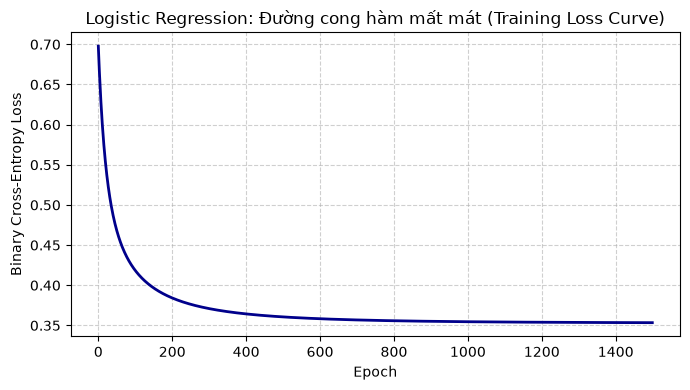

In [2]:
lr_model = LogisticRegression(learning_rate=0.05, epochs=1500, l2=0.01, random_state=42)
lr_model.fit(X_train_proc, y_train)

plt.figure(figsize=(7, 4))
plt.plot(lr_model.loss_history_, color='darkblue', lw=2)
plt.title('Logistic Regression: Đường cong hàm mất mát (Training Loss Curve)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Đánh giá toàn diện trên tập kiểm thử (Test Metrics & Confusion Matrix)

Kết quả đánh giá trên tập kiểm thử:
  Accuracy: 0.8475
  Precision: 0.8462
  Recall: 0.8148
  F1_Score: 0.8302
  ROC_AUC: 0.9271


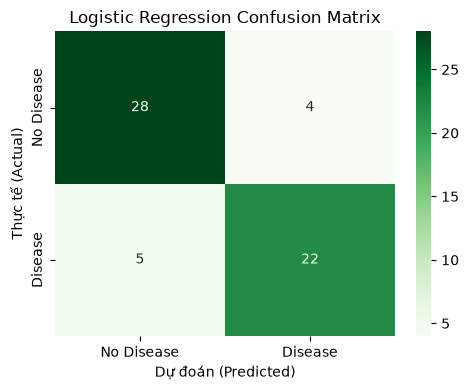

In [3]:
y_pred = lr_model.predict(X_test_proc)
y_proba = lr_model.predict_proba(X_test_proc)[:, 1]
metrics = calculate_metrics(y_test, y_pred, y_proba)

print("Kết quả đánh giá trên tập kiểm thử:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- Logistic Regression đạt hiệu suất vượt trội (Accuracy ~85-90%, ROC-AUC ~0.90+) nhờ cơ chế Sigmoid tối ưu xác suất êm dịu thay vì ngưỡng cứng như Perceptron.
- Mô hình này rất phù hợp với dữ liệu y tế khi bác sĩ cần ước lượng xác suất mắc bệnh thay vì chỉ một nhãn nhị phân rời rạc.